# 4f Edge Detection — Learning the Vortex Phase Filter

We optimise a **phase-only** filter at the Fourier plane of a 4f system to
perform edge detection.  The filter is trained end-to-end over a dataset of
random binary scenes using gradient descent, with no prior knowledge of the
analytical solution.

The optimiser should independently discover the **spiral (vortex) phase
filter** $\phi(x, y) = \arg(x + iy)$, the well-known phase-only Fourier
filter for isotropic edge enhancement.

> **Prerequisites:** the [4f correlator notebook](4f_correlator_example.ipynb)
> covers the sampling-matched focal length and 4f geometry used here.

## 0  Imports


In [1]:
from __future__ import annotations

# NOTEBOOK_REPO_ROOT_SETUP
import os
from pathlib import Path as _Path
%matplotlib inline

def _find_repo_root(start: _Path) -> _Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "fouriax").exists()
            and (candidate / "README.md").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate repository root from current working directory. "
        "Expected to find src/fouriax and README.md in an ancestor."
    )

REPO_ROOT = _find_repo_root(_Path.cwd())
if _Path.cwd() != REPO_ROOT:
    os.chdir(REPO_ROOT)


## 1  Paths and Parameters

Artifact outputs are written under `artifacts/`, including the sampled training-scene
preview figure, optimization summary JSON, and final comparison plot.


In [2]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from fouriax.optics import (
    ComplexMask,
    DetectorArray,
    Field,
    Grid,
    OpticalModule,
    Spectrum,
    ThinLens,
)
from fouriax.optics.propagation import ASMPropagator
from fouriax.optim import optimize_dataset_optical_module

ARTIFACTS_DIR = Path('artifacts')
PLOT_PATH = ARTIFACTS_DIR / "4f_edge_optimization.png"
SUMMARY_PATH = ARTIFACTS_DIR / "4f_edge_optimization_summary.json"

SEED = 0
WAVELENGTH_UM = 0.532
N_MEDIUM = 1.0
GRID_N = 128
GRID_DX_UM = 2.0
EPOCHS = 25
LR = 0.005
N_TRAIN_SCENES = 1000
N_TEST_SCENES = 100
BATCH_SIZE = 8
PLOT = True


## 2 Helper Functions


In [3]:
def random_scene(key: jax.Array, grid: Grid) -> jnp.ndarray:
    noise = jax.random.normal(key, grid.shape)
    k = jnp.fft.fftn(noise, axes=(-2, -1))
    fx, fy = grid.frequency_grid()
    sigma_freq = 1.0 / (32.0 * grid.dx_um)
    lpf = jnp.exp(-(fx**2 + fy**2) / (2 * sigma_freq**2))
    smooth = jnp.real(jnp.fft.ifftn(k * lpf, axes=(-2, -1)))
    return (smooth > 0).astype(jnp.float32)


def edge_target(scene: jnp.ndarray) -> jnp.ndarray:
    padded = jnp.pad(scene, 1, mode="edge")
    gx = padded[1:-1, 2:] - padded[1:-1, :-2]
    gy = padded[2:, 1:-1] - padded[:-2, 1:-1]
    mag = jnp.sqrt(gx**2 + gy**2)
    return mag / jnp.maximum(jnp.max(mag), 1e-12)


def sampling_matched_f(grid: Grid) -> float:
    return N_MEDIUM * grid.nx * grid.dx_um**2 / WAVELENGTH_UM


def analytical_spiral_phase(grid: Grid) -> jnp.ndarray:
    x, y = grid.spatial_grid()
    return jnp.arctan2(y, x) + jnp.pi  # [0, 2π], centered on optical axis


def make_test_scene(grid: Grid) -> jnp.ndarray:
    x, y = grid.spatial_grid()
    half = grid.nx * grid.dx_um / 2.0
    scene = jnp.zeros(grid.shape, dtype=jnp.float32)
    scene = scene + (
        (jnp.abs(x - 0.2 * half) < 0.15 * half) & (jnp.abs(y + 0.1 * half) < 0.15 * half)
    ).astype(jnp.float32)
    scene = scene + (
        (jnp.abs(x + 0.3 * half) < 0.1 * half) & (jnp.abs(y - 0.25 * half) < 0.1 * half)
    ).astype(jnp.float32)
    r = jnp.sqrt((x + 0.1 * half) ** 2 + (y + 0.3 * half) ** 2)
    scene = scene + (r < 0.12 * half).astype(jnp.float32)
    return jnp.clip(scene, 0.0, 1.0)


def measure_scenes(
    module: OpticalModule,
    scenes: jnp.ndarray,
    grid: Grid,
    spectrum: Spectrum,
) -> jnp.ndarray:
    scenes = jnp.asarray(scenes, dtype=jnp.float32)
    if scenes.ndim == 2:
        scenes = scenes[None, :, :]
    field_in = Field(
        data=scenes[:, None, :, :].astype(jnp.complex64),
        grid=grid,
        spectrum=spectrum,
    )
    return module.measure(field_in)[..., ::-1, ::-1]


## 3  Training Data

Each training scene is generated by:

1. Drawing white noise on the simulation grid.
2. Low-pass filtering in $k$-space to produce smooth blobs.
3. Thresholding at zero to obtain a binary scene.

The smoothing scale controls feature size; larger values yield bigger
blobs with fewer, longer edges.  The corresponding edge targets are
computed via central finite differences (a discrete gradient magnitude).

In [4]:
grid = Grid.from_extent(nx=GRID_N, ny=GRID_N, dx_um=GRID_DX_UM, dy_um=GRID_DX_UM)
spectrum = Spectrum.from_scalar(WAVELENGTH_UM)
f_um = sampling_matched_f(grid)

prop = ASMPropagator(
    distance_um=f_um,
    use_sampling_planner=False,
    warn_on_regime_mismatch=False,
)
lens = ThinLens(focal_length_um=f_um)

def build_module(raw_phase: jnp.ndarray) -> OpticalModule:
    phase = 2.0 * jnp.pi * jax.nn.sigmoid(raw_phase)
    return OpticalModule(
        layers=(
            prop,
            lens,
            prop,
            ComplexMask(phase_map_rad=phase),
            prop,
            lens,
            prop,
        ),
        sensor=DetectorArray(detector_grid=grid),
    )


## 4  Setup

The system follows the same geometry as the correlator notebook:

$$
\text{input}
\;\xrightarrow{\text{prop}(f)}\;
\text{Lens}_1
\;\xrightarrow{\text{prop}(f)}\;
\underbrace{e^{\,i\,\phi(x,y)}}_{\text{phase filter}}
\;\xrightarrow{\text{prop}(f)}\;
\text{Lens}_2
\;\xrightarrow{\text{prop}(f)}\;
\text{output}
$$

The phase $\phi$ is the **only trainable parameter**.  We parameterise it
as $\phi = 2\pi\,\sigma(\theta)$ where $\sigma$ is the sigmoid function
and $\theta$ is an unconstrained array optimised by Adam.

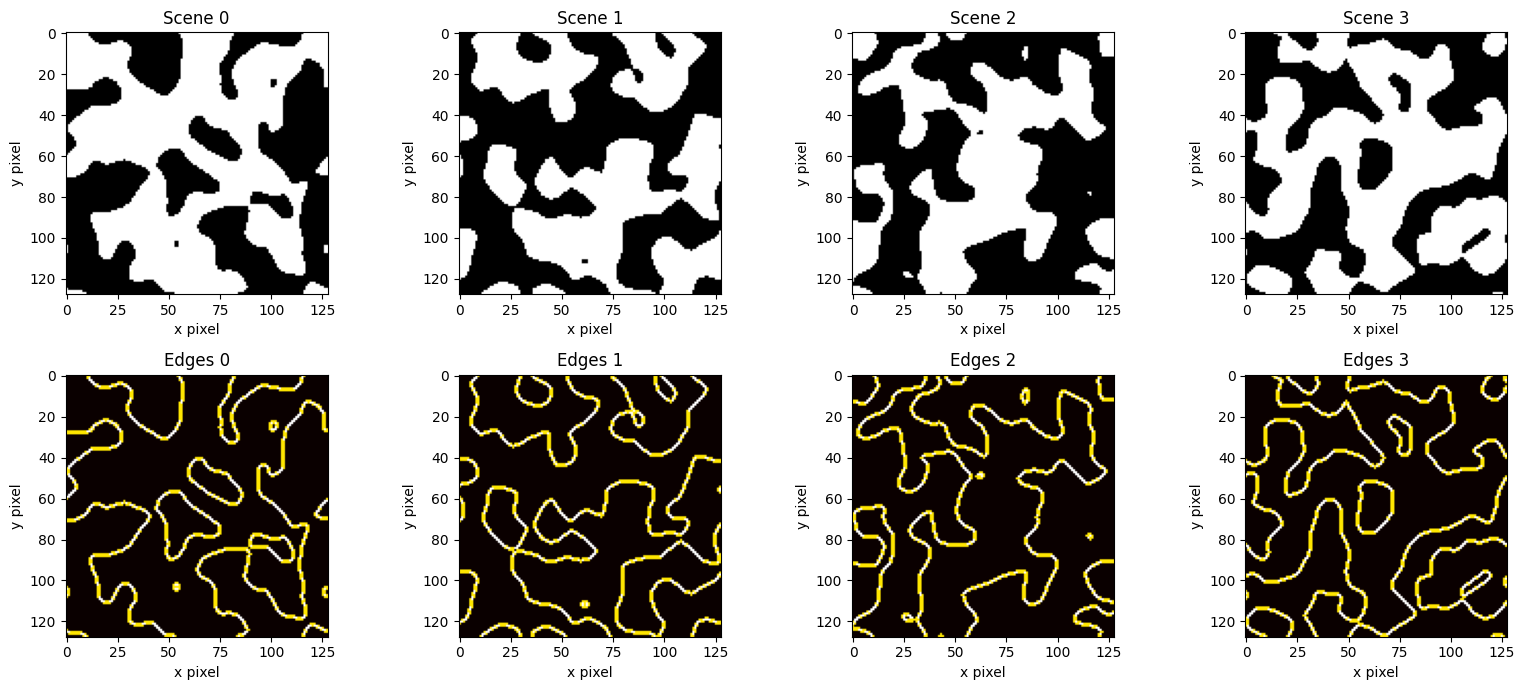

In [5]:
key = jax.random.PRNGKey(SEED)
key, *train_keys = jax.random.split(key, N_TRAIN_SCENES + 1)
train_scenes = jnp.stack([random_scene(k, grid) for k in train_keys])
train_targets = jnp.stack([edge_target(s) for s in train_scenes])
key, *test_keys = jax.random.split(key, N_TEST_SCENES + 1)
test_scenes = jnp.stack([random_scene(k, grid) for k in test_keys])
test_targets = jnp.stack([edge_target(s) for s in test_scenes])

if PLOT:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    for col in range(4):
        axes[0, col].imshow(np.asarray(train_scenes[col]), cmap="gray")
        axes[0, col].set_title(f"Scene {col}")
        axes[1, col].imshow(np.asarray(train_targets[col]), cmap="hot")
        axes[1, col].set_title(f"Edges {col}")
    for ax in axes.flat:
        ax.set_xlabel("x pixel")
        ax.set_ylabel("y pixel")
    fig.tight_layout()
    save_path = ARTIFACTS_DIR / "4f_edge_optimization_scenes.png"
    fig.savefig(save_path)
    plt.show()


## 5  Loss Function and Optimization

The loss is the mean squared error between the normalised 4f output
intensity and the target edge map.  Each gradient step uses one training
scene (SGD with batch size 1), cycling through the dataset.  Test loss
is evaluated every 50 steps on a held-out subset.

In [6]:
key, init_key = jax.random.split(key)
raw_phase = 0.1 * jax.random.normal(init_key, (grid.ny, grid.nx))
optimizer = optax.adam(LR)

n_test_eval = min(10, N_TEST_SCENES)  # evaluate on a subset for speed
val_data = (test_scenes[:n_test_eval], test_targets[:n_test_eval])

def batch_loss_fn(
    params: jnp.ndarray,
    batch: tuple[jnp.ndarray, jnp.ndarray],
) -> jnp.ndarray:
    scenes, targets = batch
    module = build_module(params)
    out = measure_scenes(module, scenes, grid, spectrum)
    out_n = out / jnp.maximum(jnp.max(out, axis=(-2, -1), keepdims=True), 1e-12)
    return jnp.mean((out_n - jnp.asarray(targets, dtype=jnp.float32)) ** 2)

result = optimize_dataset_optical_module(
    init_params=raw_phase,
    build_module=build_module,
    batch_loss_fn=batch_loss_fn,
    optimizer=optimizer,
    train_data=(train_scenes, train_targets),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    val_data=val_data,
    seed=SEED,
)
train_history = result.params_result.train_loss_history
test_history = [
    (record.step, record.metrics["val_loss"]) for record in result.params_result.val_history
]


epoch=001 step=00124 train_loss=0.092654 val_loss=0.088811 [best]


epoch=002 step=00249 train_loss=0.088286 val_loss=0.087098 [best]


epoch=003 step=00374 train_loss=0.086814 val_loss=0.086300 [best]


epoch=004 step=00499 train_loss=0.081789 val_loss=0.086031 [best]


epoch=005 step=00624 train_loss=0.083043 val_loss=0.085903 [best]


...

epoch=021 step=02624 train_loss=0.069648 val_loss=0.073618 [best]


epoch=022 step=02749 train_loss=0.070907 val_loss=0.073452 [best]


epoch=023 step=02874 train_loss=0.071992 val_loss=0.073327 [best]


epoch=024 step=02999 train_loss=0.072850 val_loss=0.073228 [best]


epoch=025 step=03124 train_loss=0.070586 val_loss=0.073184 [best]


## 6 Evaluation


In [7]:
final_phase = np.asarray(2.0 * jnp.pi * jax.nn.sigmoid(result.params_result.best_params))
test_scene = make_test_scene(grid)
test_target = edge_target(test_scene)
test_out = np.asarray(measure_scenes(result.best_module, test_scene, grid, spectrum)[0])
test_out_n = test_out / np.max(test_out)
cc = float(np.corrcoef(test_out_n.ravel(), np.asarray(test_target).ravel())[0, 1])
print(f"Test-scene correlation: {cc:.4f}")

spiral = np.asarray(analytical_spiral_phase(grid))


Test-scene correlation: 0.6223


## 7  Plot Results

The known optimal phase-only Fourier filter for isotropic edge detection
is the vortex (spiral) phase:

$$
\phi_{\text{spiral}}(x, y) = \text{atan2}(y, x) + \pi
$$

where $(x, y)$ are centred coordinates in the Fourier plane (DC at the
optical axis).  We compare the optimised phase to this analytical
solution visually.

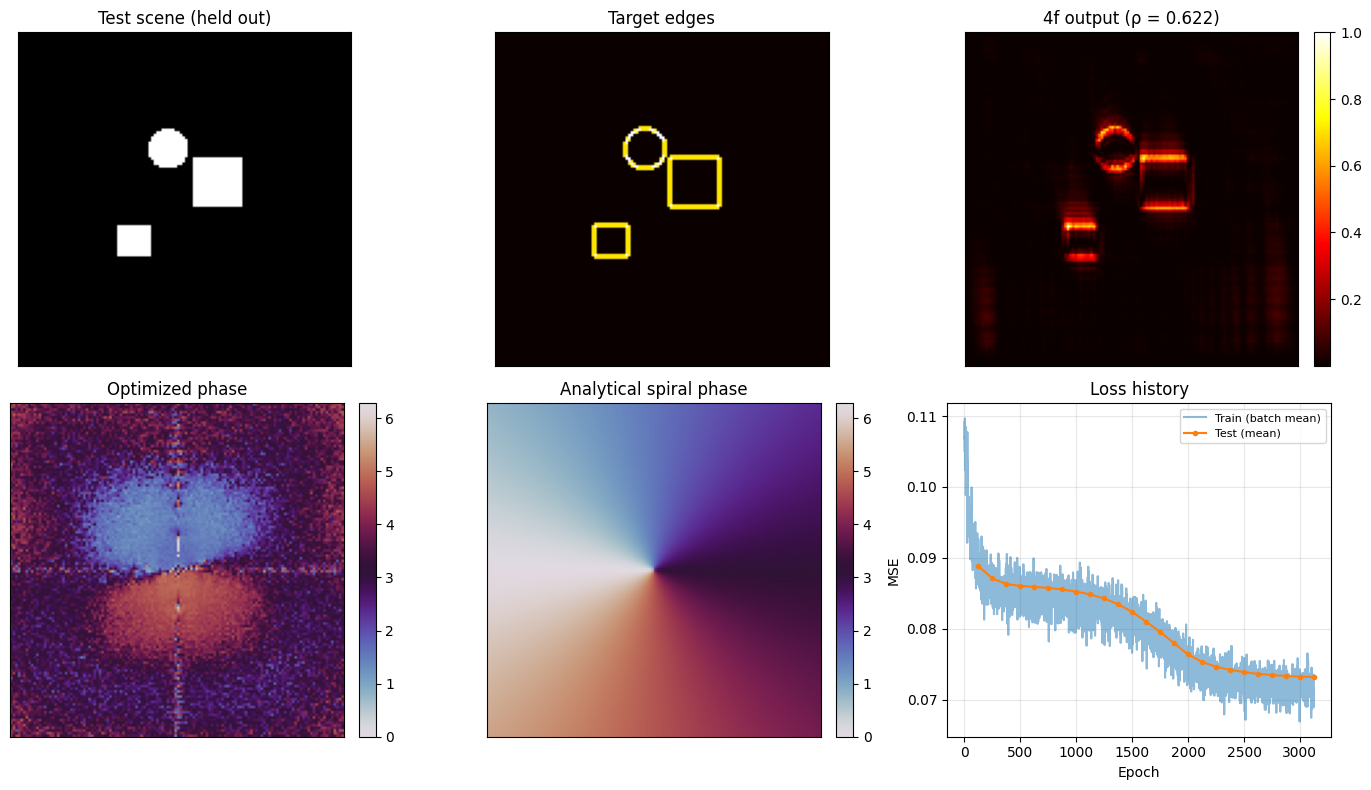

saved: artifacts/4f_edge_optimization.png


In [8]:
if PLOT:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    axes[0, 0].imshow(np.asarray(test_scene), cmap="gray")
    axes[0, 0].set_title("Test scene (held out)")

    axes[0, 1].imshow(np.asarray(test_target), cmap="hot")
    axes[0, 1].set_title("Target edges")

    im = axes[0, 2].imshow(test_out_n, cmap="hot")
    axes[0, 2].set_title(f"4f output (ρ = {cc:.3f})")
    fig.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)

    im_o = axes[1, 0].imshow(final_phase, cmap="twilight", vmin=0, vmax=2 * np.pi)
    axes[1, 0].set_title("Optimized phase")
    fig.colorbar(im_o, ax=axes[1, 0], fraction=0.046, pad=0.04)

    im_s = axes[1, 1].imshow(spiral, cmap="twilight", vmin=0, vmax=2 * np.pi)
    axes[1, 1].set_title("Analytical spiral phase")
    fig.colorbar(im_s, ax=axes[1, 1], fraction=0.046, pad=0.04)

    axes[1, 2].plot(train_history, alpha=0.5, label="Train (batch mean)")
    test_steps, test_vals = zip(*test_history, strict=True)
    axes[1, 2].plot(test_steps, test_vals, "o-", markersize=3, label="Test (mean)")
    axes[1, 2].set_title("Loss history")
    axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("MSE")
    axes[1, 2].legend(fontsize=8)
    axes[1, 2].grid(alpha=0.3)

    for ax in axes.flat:
        if ax.images:
            ax.set_xticks([])
            ax.set_yticks([])

    fig.tight_layout()
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(PLOT_PATH, dpi=150)
    plt.show()
    print(f"saved: {PLOT_PATH}")
